In [1]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import pandas as pd
import os
BASE = '/content/drive/MyDrive/DatingApp_ML'

np.random.seed(42)
N = 50000  # number of swipe events to simulate

# Each user has: [age(norm), height(norm), interests_score,
#                 activity_score, location_distance(norm)]
user_features   = np.random.rand(N, 5)
target_features = np.random.rand(N, 5)

# Simulate realistic swipe logic:
# More likely to LIKE if: similar age, close distance, common interests
age_similarity   = 1 - np.abs(user_features[:,0] - target_features[:,0])
dist_closeness   = 1 - target_features[:,4]
interest_overlap = (user_features[:,2] + target_features[:,2]) / 2

# Probability of liking
p_like = (age_similarity * 0.4 +
          dist_closeness * 0.3 +
          interest_overlap * 0.3)

labels = (np.random.rand(N) < p_like).astype(int)
print(f"Generated {N} swipe events")
print(f"Like rate: {labels.mean()*100:.1f}%")


# Input: combined feature vector of both users (10 features total)
X = np.hstack([user_features, target_features])
y = labels
print(f"X shape: {X.shape}, y shape: {y.shape}")


Mounted at /content/drive
Generated 50000 swipe events
Like rate: 56.7%
X shape: (50000, 10), y shape: (50000,)


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build ANN
# Input: 10 features (5 user + 5 target)
# Output: 1 score (probability of liking = compatibility score)
model = Sequential([
    Dense(128, activation='relu', input_shape=(10,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')  # compatibility score 0 to 1
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

CKPT = f'{BASE}/models/recommendation_model.h5'
callbacks = [
    ModelCheckpoint(CKPT, save_best_only=True, monitor='val_auc', verbose=1),
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_auc')
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)
print(f"\nModel saved: {CKPT}")


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


148/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5664 - auc: 0.5707 - loss: 0.7343
Epoch 1: val_auc improved from None to 0.62032, saving model to /content/drive/MyDrive/DatingApp_ML/models/recommendation_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/DatingApp_ML/models/recommendation_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5772 - auc: 0.5861 - loss: 0.7047 - val_accuracy: 0.5654 - val_auc: 0.6203 - val_loss: 0.6816
Epoch 2/30
148/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5965 - auc: 0.6145 - loss: 0.6728
Epoch 2: val_auc improved from 0.62032 to 0.64405, saving model to /content/drive/MyDrive/DatingApp_ML/models/recommendation_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/DatingApp_ML/models/recommendation_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5995 - auc: 0.6182 - loss: 0.6695 - val_accuracy: 0.5810 - val_auc: 0.6440 - val_loss: 0.6661
Epoch 3/30
148/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6113 - auc: 0.6355 - loss: 0.6596
Epoch 3: val_auc improved from 0.64405 to 0.65807, saving model to /content/drive/MyDrive/DatingApp_ML/models/recommendation_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/DatingApp_ML/models/recommendation_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6140 - auc: 0.6379 - loss: 0.6575 - val_accuracy: 0.6248 - val_auc: 0.6581 - val_loss: 0.6477
Epoch 4/30
147/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6150 - auc: 0.6397 - loss: 0.6558
Epoch 4: val_auc improved from 0.65807 to 0.66226, saving model to /content/drive/MyDrive/DatingApp_ML/models/recommendation_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/DatingApp_ML/models/recommendation_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6167 - auc: 0.6412 - loss: 0.6548 - val_accuracy: 0.6301 - val_auc: 0.6623 - val_loss: 0.6434
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6200 - auc: 0.6501 - loss: 0.6513
Epoch 5: val_auc did not improve from 0.66226
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6213 - auc: 0.6509 - loss: 0.6497 - val_accuracy: 0.6271 - val_auc: 0.6611 - val_loss: 0.6442
Epoch 6/30
153/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6209 - auc: 0.6511 - loss: 0.6502
Epoch 6: val_auc did not improve from 0.66226
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6235 - auc: 0.6533 - loss: 0.6487 - val_accuracy: 0.6279 - val_auc: 0.6601 - val_loss: 0.6448
Epoch 7/30
153/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6291 - auc: 0.6609 - loss: 0.6448
Epoch 7: val_auc did not improve from 0.66226
157/157 ━━━━━

Test Accuracy: 63.0%
AUC Score: 0.662


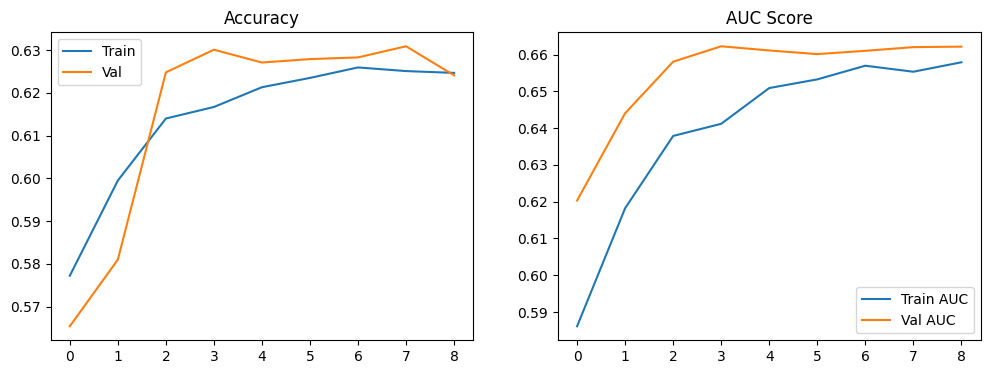


Top 5 recommendations:
  Rank 1: Candidate #97 — 84.5% compatibility
  Rank 2: Candidate #62 — 84.1% compatibility
  Rank 3: Candidate #38 — 80.5% compatibility
  Rank 4: Candidate #68 — 79.8% compatibility
  Rank 5: Candidate #65 — 79.4% compatibility


In [3]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Evaluate
loss, accuracy, auc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy*100:.1f}%")
print(f"AUC Score: {auc:.3f}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC Score')
axes[1].legend()
plt.savefig(f'{BASE}/results/recommendation_training.png', dpi=150)
plt.show()

# Example: get top recommendations for a new user
def get_recommendations(user_vector, candidate_pool, model, top_k=10):
    """
    Given a user's feature vector and a pool of candidates,
    return the top_k most compatible candidates.
    """
    scores = []
    for i, candidate in enumerate(candidate_pool):
        combined = np.concatenate([user_vector, candidate]).reshape(1, -1)
        score = float(model.predict(combined, verbose=0)[0][0])
        scores.append((i, round(score * 100, 1)))

    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]

# Simulate a new user and 100 candidates
new_user = np.random.rand(5)
candidates = np.random.rand(100, 5)
recs = get_recommendations(new_user, candidates, model)

print("\nTop 5 recommendations:")
for rank, (idx, score) in enumerate(recs[:5], 1):
    print(f"  Rank {rank}: Candidate #{idx} — {score}% compatibility")
